In [32]:
import pandas as pd
import json
import geopandas as gpd
import plotly.express as px

county ="Collin"

csv_file = f"{county}_diabetes_data.csv"   
df = pd.read_csv(csv_file, dtype={'TractFIPS': str})

df['TractFIPS'] = df['TractFIPS'].str.zfill(11)

shapefile_path = "../Census_Tract/tl_2025_48_tract.shp"   
gdf = gpd.read_file(shapefile_path)

# need to change county code here (FIPS code) 
# this is the link with the codes: https://www.dshs.texas.gov/center-health-statistics/texas-county-numbers-public-health-regions
county_gdf = gdf[gdf["COUNTYFP"] == "085"].copy() 

final_county_gdf = county_gdf.to_crs(epsg=4326)

# find the center of the county 
centroid = final_county_gdf.geometry.union_all().centroid
print(centroid.y, centroid.x) 

33.187989808190295 -96.5724294261454


Collin tracts in shapefile: 220


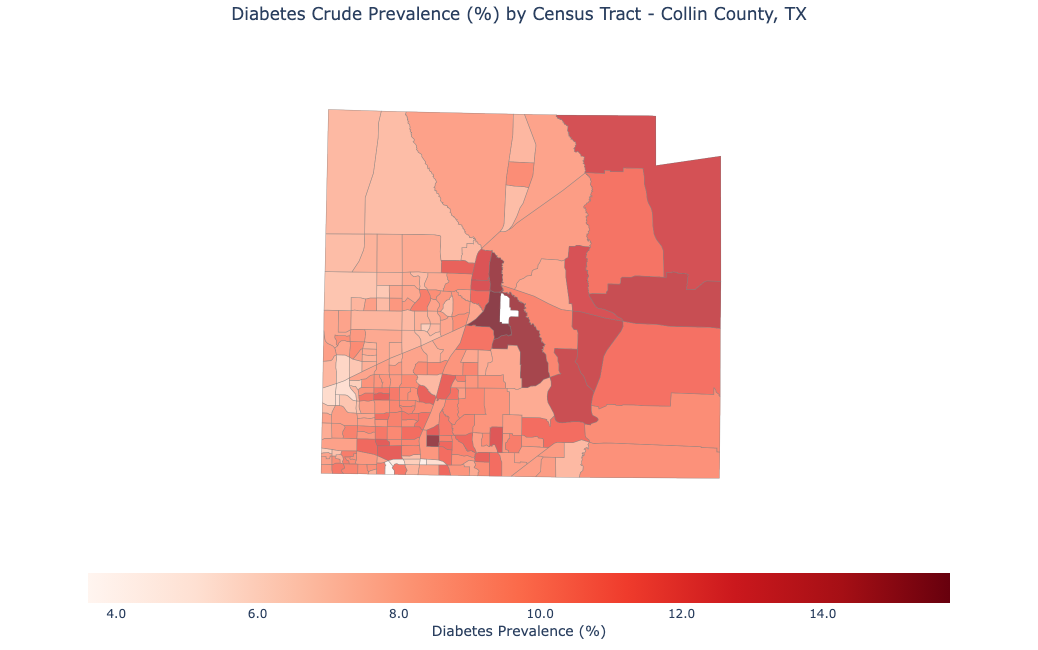

In [33]:
geojson_data = json.loads(final_county_gdf.to_json())

print(f"{county} tracts in shapefile:", len(final_county_gdf))

min_val = df['DIABETES_CrudePrev'].min()
max_val = df['DIABETES_CrudePrev'].max()

fig = px.choropleth_map(
    df,
    geojson=geojson_data,
    locations='TractFIPS',               
    color='DIABETES_CrudePrev',          
    color_continuous_scale="Reds",
    range_color=(min_val, max_val),
    featureidkey="properties.GEOID",     
    map_style="white-bg",      
    zoom=9,
    opacity=0.75,
    
    # need to change coordinates based on calculation above 
    center={"lat": 33.187989808190295, "lon":-96.5724294261454 },   
    
    title=f"Diabetes Crude Prevalence (%) by Census Tract - {county} County, TX",
    hover_data={
        'DIABETES_CrudePrev': True,
        'DIABETES_Crude95CI': True,
        'TractFIPS': True,
    },
    labels={
        'DIABETES_CrudePrev': 'Diabetes Prevalence (%)',
        'DIABETES_Crude95CI': '95% CI',
        'TractFIPS': 'Tract FIPS',
    },
)

fig.update_traces(
    marker_line_width=0.5,
    marker_line_color='#888888',
)

fig.update_layout(
    width=900,
    height=650,
    margin={"r": 0, "t": 40, "l": 0, "b": 0},
    title={'xanchor': 'center', 'x': 0.5},
    coloraxis_colorbar={
        'title': 'Diabetes Prevalence (%)',
        'title_side': 'bottom',
        'tickformat': '.1f',
        'orientation': 'h',
        'x': 0.5,
        'xanchor': 'center',
        'y': -0.01,
        'yanchor': 'top',
        'len': 0.85,
    },
)

fig.show()